In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [100]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015/7/1
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015/7/1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015/7/2
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015/7/2
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015/7/3


# 数据预处理

In [101]:
df = df[df['is_canceled'] == 0]
df = df[df['hotel']=='City Hotel']

In [102]:
# 使用箱形图（IQR）方法剔除 adr（房价）异常值
q1 = df['lead_time'].quantile(0.25)
q3 = df['lead_time'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

before_rows = len(df)
df = df[(df['lead_time'] >= lower_bound) & (df['lead_time'] <= upper_bound)]
after_rows = len(df)

print(f"lead_time 下界: {lower_bound:.2f}, 上界: {upper_bound:.2f}")
print(f"剔除异常记录数: {before_rows - after_rows}")
print(f"清洗后记录数: {after_rows}")

lead_time 下界: -151.50, 上界: 284.50
剔除异常记录数: 1856
清洗后记录数: 44372


In [103]:
room_types = df['reserved_room_type'].unique()
room_types


array(['A', 'F', 'B', 'D', 'E', 'G', 'C'], dtype=object)

In [104]:
# 使用箱形图（IQR）方法剔除 lead_time（预订提前时间）异常值
for room_type in room_types:
    q1 = df[df['reserved_room_type'] == room_type]['lead_time'].quantile(0.25)
    q3 = df[df['reserved_room_type'] == room_type]['lead_time'].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    before_rows = len(df)
    mask_room = df['reserved_room_type'] == room_type
    mask_iqr = (df['lead_time'] >= lower_bound) & (df['lead_time'] <= upper_bound)
    df = df[~mask_room | (mask_room & mask_iqr)]
    after_rows = len(df)

    print(f"房型: {room_type}")
    print(f"lead_time 下界: {lower_bound:.2f}, 上界: {upper_bound:.2f}")
    print(f"剔除异常记录数: {before_rows - after_rows}")
    print(f"清洗后记录数: {after_rows}")

房型: A
lead_time 下界: -141.50, 上界: 262.50
剔除异常记录数: 531
清洗后记录数: 43841
房型: F
lead_time 下界: -138.00, 上界: 246.00
剔除异常记录数: 15
清洗后记录数: 43826
房型: B
lead_time 下界: -178.25, 上界: 347.75
剔除异常记录数: 0
清洗后记录数: 43826
房型: D
lead_time 下界: -122.00, 上界: 246.00
剔除异常记录数: 69
清洗后记录数: 43757
房型: E
lead_time 下界: -115.75, 上界: 214.25
剔除异常记录数: 12
清洗后记录数: 43745
房型: G
lead_time 下界: -96.50, 上界: 175.50
剔除异常记录数: 18
清洗后记录数: 43727
房型: C
lead_time 下界: -171.00, 上界: 285.00
剔除异常记录数: 0
清洗后记录数: 43727


In [105]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,43727.0,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,43727.000000,38228.000000,2905.000000,43727.000000,43727.000000,43727.000000,43727.000000
mean,0.0,66.069957,2016.165230,26.960619,15.705194,0.808471,2.116221,1.826011,0.102042,0.007432,0.036385,0.022366,0.219864,0.258627,27.302344,143.195869,1.067853,105.939907,0.043726,0.741007
std,0.0,65.756612,0.694086,13.752210,8.763362,0.860787,1.408017,0.541053,0.389295,0.106568,0.187248,0.346377,2.183149,0.695254,54.701064,119.933759,8.909530,41.193429,0.205380,0.837776
min,0.0,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,10.000000,2016.000000,15.500000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,40.000000,0.000000,80.000000,0.000000,0.000000
50%,0.0,44.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,91.000000,0.000000,99.330000,0.000000,1.000000
75%,0.0,105.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,219.000000,0.000000,127.800000,0.000000,1.000000
max,0.0,280.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,4.000000,3.000000,10.000000,1.000000,13.000000,72.000000,21.000000,509.000000,497.000000,223.000000,510.000000,3.000000,5.000000


# 预订提前期探索

Text(0.5, 0, 'Lead Time (days)')

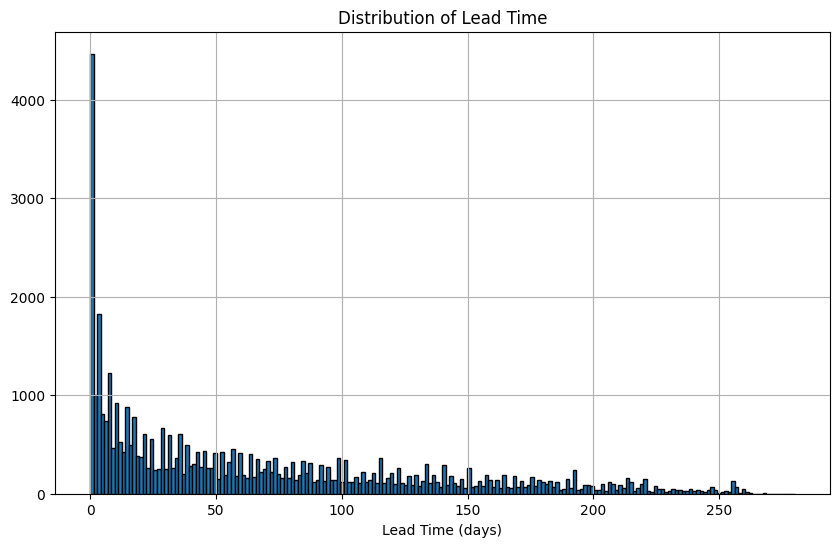

In [106]:
# Plotting the distribution of lead_time
plt.figure(figsize=(10, 6))
df['lead_time'].hist(bins=200, edgecolor='black')
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')

# 价格探索

In [113]:
df.groupby('reserved_room_type')['adr'].aggregate(['mean', 'std', 'min', 'max','count'])

,mean,std,min,max,count
reserved_room_type,,,,,
A,96.375944,32.357672,0.0,510.00,33080
B,87.005903,34.326633,0.0,263.55,703
C,68.111111,55.525770,0.0,130.00,9
D,128.194407,38.553305,0.0,375.50,7491
E,153.448947,52.167266,0.0,451.50,1035
F,185.330235,53.969037,0.0,349.63,1064
G,191.955304,94.529322,0.0,372.33,345


Text(0.5, 1.0, 'Boxplot of ADR by Reserved Room Type')

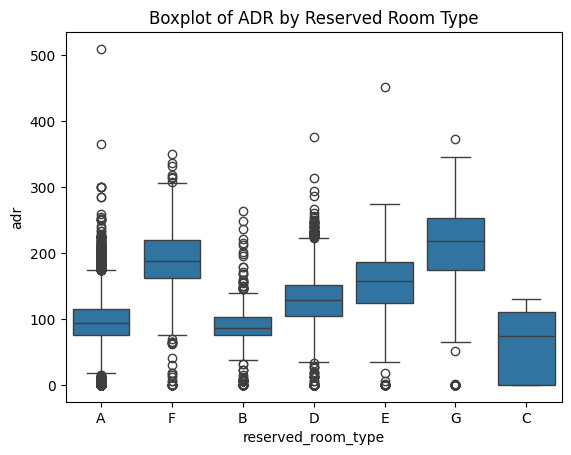

In [108]:
sns.boxplot(x='reserved_room_type', y='adr', data=df)
plt.title('Boxplot of ADR by Reserved Room Type')

# 旅行社和价格的描述

In [110]:
df['agent'].fillna(0, inplace=True)

/var/folders/9y/l07k1cmx4vl4kgw_tml08fxc0000gn/T/ipykernel_43714/2085200365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agent'].fillna(0, inplace=True)


In [114]:
print(df.groupby('agent')['adr'].aggregate(['mean', 'std', 'min', 'max','count']).to_string())

             mean        std     min     max  count
agent                                              
0.0     87.708522  44.708015    0.00  451.50   5499
1.0     74.838625  36.256233    0.00  250.00   1745
2.0     82.647576  40.716835    0.00  144.50     33
3.0     80.530725  27.754824    0.00  160.60    483
4.0     65.543750  25.923521    0.00   76.67     16
6.0     91.414518  30.522340    0.00  174.25    841
7.0     94.362705  35.949599    0.00  307.80   3017
8.0    119.868368  46.933857    0.00  321.50    827
9.0    123.063552  36.633077    0.00  375.50  18306
10.0    94.366054  25.892175    0.00  195.70    185
11.0    73.180386  19.880512    0.00  147.71    259
12.0    91.013934  24.790464    0.00  160.00    211
13.0   102.174211  23.538758   63.75  165.00     57
14.0   125.343036  46.183151    0.00  372.33   2928
15.0    93.143953  31.955520    0.00  167.04    129
16.0    89.158333  22.531049   37.07  206.28    210
17.0    88.962698  25.380656    0.00  138.50    126
19.0    90.6